# Modelo ResNet

Probamos ha hacer fine-tuning con el modelo ResNet, con sus pesos ya inicializados.

In [1]:
import sys
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_path = '/content/eye_diseases_classification_trabajo_DL'
    if not os.path.exists(repo_path):
        !git clone https://github.com/ropas5/eye_diseases_classification_trabajo_DL.git
        sys.path.append('/content/eye_diseases_classification_trabajo_DL/notebooks')
    # from google.colab import userdata
    # userdata.get('kaggle')
    else:
        print("Repo ya existe, actualizando")
        %cd /content/eye_diseases_classification_trabajo_DL/notebooks
        !git pull 
        
    #Cargamos el kaggle.json
    import ipywidgets as widgets
    from IPython.display import display
    
    uploader = widgets.FileUpload(accept='.json')
    display(uploader)
else:
    print("Ejecución en local")
    uploader = None

Cloning into 'eye_diseases_classification_trabajo_DL'...
remote: Enumerating objects: 324, done.
remote: Counting objects: 100% (324/324), done.
remote: Compressing objects: 100% (197/197), done.
remote: Total 324 (delta 151), reused 260 (delta 108), pack-reused 0 (from 0)
Receiving objects: 100% (324/324), 5.33 MiB | 21.14 MiB/s, done.
Resolving deltas: 100% (151/151), done.


FileUpload(value={}, accept='.json', description='Upload')

### Impotacion y preprocesado de datos

In [10]:
from importacion_preprocesado_2 import descarga_y_carga_de_datos, preprocesamiento


tamany_img = (128,128) # tamaño reducido para colab, porque si no supera la ram
X, y = descarga_y_carga_de_datos(target_size=tamany_img, uploader=uploader)

X_train, X_val, X_test, y_train, y_val, y_test = preprocesamiento(X, y)

Dataset no encontrado, descargando y extrayendo...
Dataset extraído en: data/raw/dataset
X shape: (4217, 128, 128, 3) y shape: (4217,)


### Modelo

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# ========== OPCIÓN 1: ResNet50 (RECOMENDADO) ==========


# Cargar ResNet50 pre-entrenado (sin capas finales)
restnet = ResNet50(
  weights='imagenet',  # Pre-entrenado en ImageNet
  input_shape=(128,128,3),
  include_top=False  # Sin capa de salida (la agregaremos nosotros)
)

for layers in restnet.layers:
    layers.trainable = False


# restnet.summary()

In [14]:
# CREAR modelo personalizado
model = Sequential()

# Agregar capas personalizadas para nuestro problema
model.add(restnet)


model.add(GlobalAveragePooling2D())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4, activation='softmax'))

# Compilar
optimizer = Adam(learning_rate=0.0001)
model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy']
)



In [15]:
hist = model.fit(X_train, y_train, validation_data= (X_val, y_val), epochs= 70)

Epoch 1/70
80/80 ━━━━━━━━━━━━━━━━━━━━ 446s 5s/step - accuracy: 0.2501 - loss: 1.4788 - val_accuracy: 0.2405 - val_loss: 1.3681
Epoch 2/70
80/80 ━━━━━━━━━━━━━━━━━━━━ 392s 5s/step - accuracy: 0.2827 - loss: 1.4133 - val_accuracy: 0.3957 - val_loss: 1.3493
Epoch 3/70
80/80 ━━━━━━━━━━━━━━━━━━━━ 460s 6s/step - accuracy: 0.2721 - loss: 1.3986 - val_accuracy: 0.4846 - val_loss: 1.3358
Epoch 4/70
80/80 ━━━━━━━━━━━━━━━━━━━━ 423s 5s/step - accuracy: 0.3118 - loss: 1.3781 - val_accuracy: 0.4052 - val_loss: 1.3157
Epoch 5/70
80/80 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.3213 - loss: 1.3651 - val_accuracy: 0.4834 - val_loss: 1.3001
Epoch 6/70
80/80 ━━━━━━━━━━━━━━━━━━━━ 352s 4s/step - accuracy: 0.3463 - loss: 1.3430 - val_accuracy: 0.4017 - val_loss: 1.2828
Epoch 7/70
80/80 ━━━━━━━━━━━━━━━━━━━━ 333s 4s/step - accuracy: 0.3532 - loss: 1.3499 - val_accuracy: 0.4479 - val_loss: 1.2757
Epoch 8/70
80/80 ━━━━━━━━━━━━━━━━━━━━ 480s 5s/step - accuracy: 0.3715 - loss: 1.3227 - val_accuracy: 0.4396 - v

: 

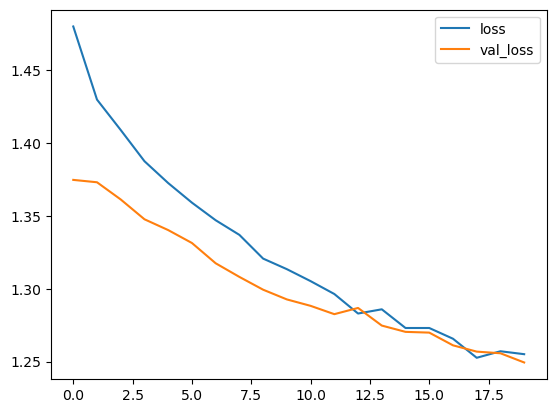

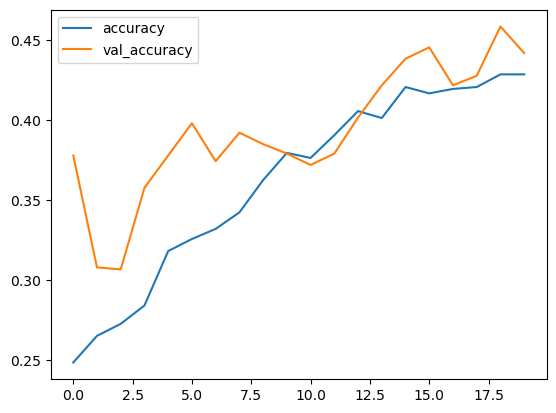

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Fijamos un estilo
# style = "ggplot"
# plt.style.use(style)

# número de épocas para el zoom
zoom_epochs = 20

loss = hist.history['loss']
val_loss = hist.history['val_loss']
acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]

epochs = range(1, len(loss) + 1)

fig, ax = plt.subplots(2, 2, figsize=(13,10))
ax  = ax.flatten()
fig.suptitle('Training History', fontsize=15, fontweight='bold')

# Visualizacion evolucion loss durante el entrenamiento
ax[0].plot( loss, label='Train loss', color = "blue")
ax[0].plot( val_loss, label='Val loss', color= "yellow")
ax[0].set_title('Training loss evolution')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].grid(True, alpha = 0.4)
ax[0].legend()

# Zoom últimas épocas
ax[1].plot(epochs[-zoom_epochs:], loss[-zoom_epochs:], label='Train loss', color = "blue")
ax[1].plot(epochs[-zoom_epochs:], val_loss[-zoom_epochs:], label='Val loss', color= "yellow")
ax[1].set_title(f'Zoom últimas {zoom_epochs} epocas')
ax[1].set_xlabel('Epoch')
ax[1].grid(True, alpha = 0.4)
ax[1].legend()

# Visualizacion de accuracy durante el entrenamiento
ax[2].plot( acc, label='Train accuracy', color = "blue")
ax[2].plot( val_acc, label='Val accuracy', color= "yellow")
ax[2].grid(True, alpha = 0.4)
ax[2].set_ylim(0,1)
ax[2].set_title('Training accuracy evolution')
ax[2].set_ylabel('accuracy')
ax[2].legend()

# Zoom últimas épocas
ax[3].plot(epochs[-zoom_epochs:], acc[-zoom_epochs:], label='Train accuracy', color = "blue")
ax[3].plot(epochs[-zoom_epochs:], val_acc[-zoom_epochs:], label='Val accuracy', color= "yellow")
ax[3].set_title(f'Zoom últimas {zoom_epochs} epocas')
ax[3].grid(True, alpha = 0.4)
ax[3].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

datasets = {
    "Train": (X_train, y_train),
    "Val": (X_val, y_val),
    "Test": (X_test, y_test)
}

def evaluate(model, X, y):
    #Convertir a enteros
    y_true = np.argmax(y, axis=1)

    y_pred_probs = model.predict(X)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return acc, f1


def crear_df_metricas(model, datasets):
    results = {}
    for split_name, (X, y) in datasets.items():
        acc, f1 = evaluate(model, X, y)
        results[split_name] = [acc, f1]
    
    df = pd.DataFrame(results, index=["Accuracy", "F1"])
    return df

In [ ]:
df = crear_df_metricas(model, datasets)
print(df.round(3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step
          Train    Val   Test
Accuracy  0.450  0.442  0.451
F1        0.406  0.403  0.415


In [ ]:
def plot_barra(metrica, titulo, color):

    plt.figure(figsize=(6,4))
    bars = plt.bar(metrica.index, metrica.values, color=color)
    plt.bar_label(bars)
    plt.title(f"{titulo}: Train vs Validation vs Test")
    plt.ylabel(titulo)
    plt.ylim(0,1)
    plt.grid(axis='y', linestyle='--')
    plt.show()


def plots_metricas(df):
    #Extraemos la fila
    accuracy = df.loc["Accuracy"]
    f1 = df.loc["F1"]

    #Grafico de Accuracy
    plot_barra(accuracy, titulo = "Accuracy", color="blue")

    #Grafico de 
    plot_barra(f1, titulo ="F1", color = "red")

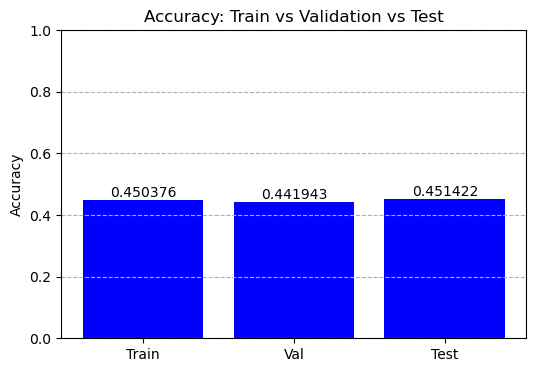

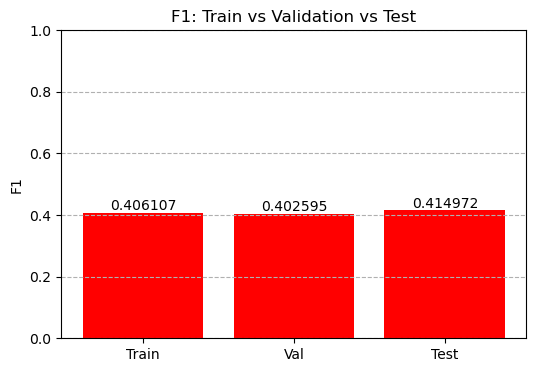

In [ ]:
plots_metricas(df)

27/27 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step


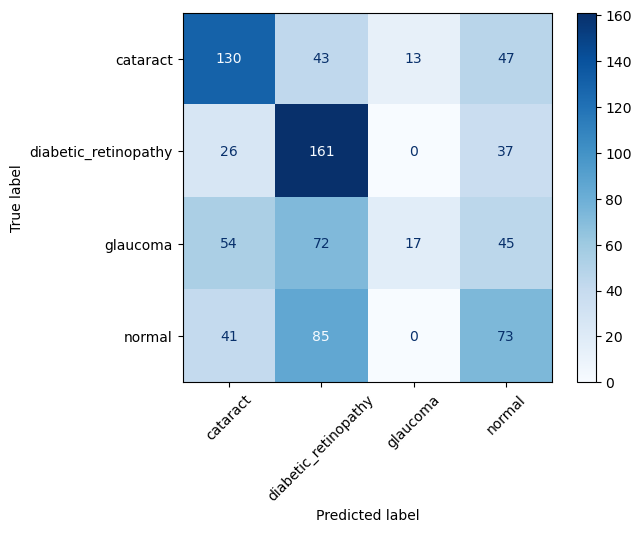

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm,  
                    display_labels= ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
                    ).plot(cmap="Blues", xticks_rotation= 45.0)

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def per_class_table(model, datasets):
    # class_names: lista con nombres de las clases en el orden de los índices (opcional)
    class_names = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]  

    splits = list(datasets.keys())
    # identificamos número de clases desde los datos si no dan nombres
    sample_X, sample_y = next(iter(datasets.values()))
    n_classes = np.argmax(sample_y, axis=1).max() + 1

    # DataFrame con index = clases y columnas por split/metric
    cols = []
    for s in splits:
        cols += [f"{s}_Accuracy", f"{s}_F1"]
    df = pd.DataFrame(index=class_names, columns=cols, dtype=float)

    for split in splits:
        X, y = datasets[split]
        y_true = np.argmax(y, axis=1)
        y_pred = np.argmax(model.predict(X), axis=1)

        # precision, recall, f1 por clase
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=np.arange(n_classes), zero_division=0
        )
        # Aquí definimos "Accuracy" por clase como recall (TP / nº verdaderos de la clase)
        for i, cls in enumerate(class_names):
            df.loc[cls, f"{split}_Accuracy"] = recall[i]
            df.loc[cls, f"{split}_F1"] = f1[i]

    return df

In [ ]:
df_per_class = per_class_table(model, datasets)
print(df_per_class.round(3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step
                      Train_Accuracy  Train_F1  Val_Accuracy  Val_F1  \
cataract                       0.568     0.527         0.596   0.540   
diabetic_retinopathy           0.757     0.549         0.684   0.526   
glaucoma                       0.080     0.141         0.082   0.143   
normal                         0.394     0.408         0.363   0.376   

                      Test_Accuracy  Test_F1  
cataract                      0.558    0.537  
diabetic_retinopathy          0.719    0.550  
glaucoma                      0.090    0.156  
normal                        0.367    0.364  


: 

Resultado resnet:
          Train    Val   Test
Accuracy  0.484  0.468  0.469
F1        0.445  0.431  0.439

resultDO VGG:
          Train    Val   Test
Accuracy  0.811  0.808  0.807
F1        0.811  0.809  0.807
